# 👾 PixelCNN using Tensorflow distributions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DiveshJ8/Generative_Deep_Learning_2nd_Edition/blob/feature/assignment_week3/notebooks/05_autoregressive/03_pixelcnn_md/pixelcnn_md.ipynb)

In this notebook, we'll walk through the steps required to train your own PixelCNN on the fashion MNIST dataset using Tensorflow distributions


In [9]:
# Setup for Google Colab and local environments
import os
import sys

# Configure TensorFlow to use legacy Keras 2 (tf_keras) required by TensorFlow Probability
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Python 3.12+ compatibility fix: 'imp' was removed in Python 3.12+, but legacy extensions may import it
if 'imp' not in sys.modules:
    try:
        import imp
    except ImportError:
        import importlib
        import types
        _imp = types.ModuleType('imp')
        _imp.reload = importlib.reload
        sys.modules['imp'] = _imp


# 1. If running in Google Colab, clone the repository branch and navigate into it
if "google.colab" in sys.modules:
    if os.path.exists("/content"):
        %cd /content
    if not os.path.exists("Generative_Deep_Learning_2nd_Edition"):
        !git clone -b feature/assignment_week3 https://github.com/DiveshJ8/Generative_Deep_Learning_2nd_Edition.git
    %cd /content/Generative_Deep_Learning_2nd_Edition
    if os.path.abspath(".") not in sys.path:
        sys.path.append(os.path.abspath("."))
    # Install required packages in Colab (tf-keras is required for TFP compatibility on TF 2.16+)
    %pip install -q tensorflow-probability tf-keras tensorboard matplotlib

# 2. Add repository root to sys.path if running locally outside repository root
repo_root = None
for candidate in [
    os.path.abspath(os.path.join(os.getcwd(), "../../..")),
    os.path.abspath(os.getcwd()),
    os.path.abspath("/content/Generative_Deep_Learning_2nd_Edition"),
    "/app",
]:
    if os.path.exists(os.path.join(candidate, "notebooks")):
        repo_root = candidate
        break
if repo_root is None:
    repo_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if repo_root not in sys.path:
    sys.path.append(repo_root)

# 3. Ensure required packages are installed
try:
    import tensorflow
except ImportError:
    %pip install -q tensorflow

try:
    import tensorflow_probability
except ImportError:
    %pip install -q tensorflow-probability

try:
    import tf_keras
except ImportError:
    %pip install -q tf-keras

try:
    import tensorboard
except ImportError:
    %pip install -q tensorboard

try:
    import matplotlib
except ImportError:
    %pip install -q matplotlib


/content
/content/Generative_Deep_Learning_2nd_Edition


In [10]:
# Configure Keras to use legacy tf_keras for compatibility with TensorFlow Probability
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Python 3.12+ compatibility shim for 'imp' (used by legacy autoreload)
import sys
if 'imp' not in sys.modules:
    try:
        import imp
    except ImportError:
        import importlib
        import types
        _imp = types.ModuleType('imp')
        _imp.reload = importlib.reload
        sys.modules['imp'] = _imp

# Enable autoreload if available and supported
try:
    %load_ext autoreload
    %autoreload 2
except Exception:
    pass

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

# TensorFlow Probability's PixelCNN requires Keras 2 (tf_keras in TF 2.16+)
try:
    import tf_keras as keras
    from tf_keras import datasets, layers, models, optimizers, callbacks
except (ImportError, ModuleNotFoundError):
    from tensorflow.keras import datasets, layers, models, optimizers, callbacks

# Import display utility from notebooks.utils with standalone fallback
try:
    from notebooks.utils import display
except ModuleNotFoundError:
    import matplotlib.pyplot as plt

    def display(
        images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
    ):
        """
        Displays n random images from each one of the supplied arrays.
        """
        if images.max() > 1.0:
            images = images / 255.0
        elif images.min() < 0.0:
            images = (images + 1.0) / 2.0

        plt.figure(figsize=size)
        for i in range(n):
            _ = plt.subplot(1, n, i + 1)
            plt.imshow(images[i].astype(as_type), cmap=cmap)
            plt.axis("off")

        if save_to:
            import os
            os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
            plt.savefig(save_to)
            print(f"\nSaved to {save_to}")

        plt.show()

print(f"TensorFlow version: {tf.__version__}")
try:
    print(f"Keras backend: {keras.__name__} (v{getattr(keras, '__version__', '2')})")
except Exception:
    pass
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU available: {bool(gpus)}")
if gpus:
    print(f"🚀 Using GPU: {gpus[0].name}")
else:
    print("ℹ️ Running on CPU")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TensorFlow version: 2.20.0
Keras backend: tf_keras (v2.20.1)
GPU available: True
🚀 Using GPU: /physical_device:GPU:0


## 0. Parameters <a name="parameters"></a>

In [11]:
IMAGE_SIZE = 32
N_COMPONENTS = 5
EPOCHS = 10
BATCH_SIZE = 128

## 1. Prepare the data <a name="prepare"></a>

In [12]:
# Load the data
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

In [13]:
# Preprocess the data


def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()
    return imgs


input_data = preprocess(x_train)

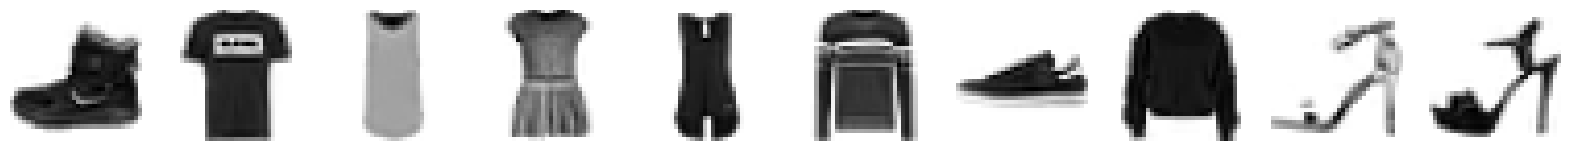

In [14]:
# Show some items of clothing from the training set
display(input_data)

## 2. Build the PixelCNN <a name="build"></a>

In [15]:
# Ensure layers and models use tf_keras for TensorFlow Probability compatibility
try:
    import tf_keras as keras
    from tf_keras import layers, models
except (ImportError, ModuleNotFoundError):
    from tensorflow.keras import layers, models

# Define a Pixel CNN network
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,
    num_hierarchies=2,
    num_filters=32,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)

# Define the model input
image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

# Define the log likelihood for the loss fn
log_prob = dist.log_prob(image_input)

# Define the model
pixelcnn = models.Model(inputs=image_input, outputs=log_prob)
pixelcnn.add_loss(-tf.reduce_mean(log_prob))


## 3. Train the PixelCNN <a name="train"></a>

In [16]:
# Compile and train the model
pixelcnn.compile(
    optimizer=optimizers.Adam(0.001),
)

In [17]:
import os

os.makedirs("./output", exist_ok=True)
os.makedirs("./logs", exist_ok=True)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        return dist.sample(self.num_img).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        display(
            generated_images,
            n=self.num_img,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )


img_generator_callback = ImageGenerator(num_img=2)

Layer _PixelCNNNetwork was created by passing
non-serializable argument values in `__init__()`,
and therefore the layer must override `get_config()` in
order to be serializable. Please implement `get_config()`.

Example:

class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2, **kwargs):
        super().__init__(**kwargs)
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config


Epoch 1/10
  6/469 [..............................] - ETA: 1:49 - loss: 4099.5176

469/469 [==============================] - ETA: 0s - loss: 2361.1145
Saved to ./output/generated_img_000.png


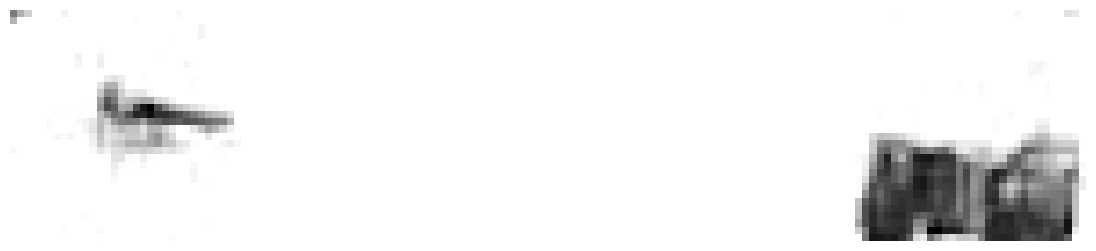

469/469 [==============================] - 237s 454ms/step - loss: 2361.1145
Epoch 2/10
469/469 [==============================] - ETA: 0s - loss: 2079.1472
Saved to ./output/generated_img_001.png


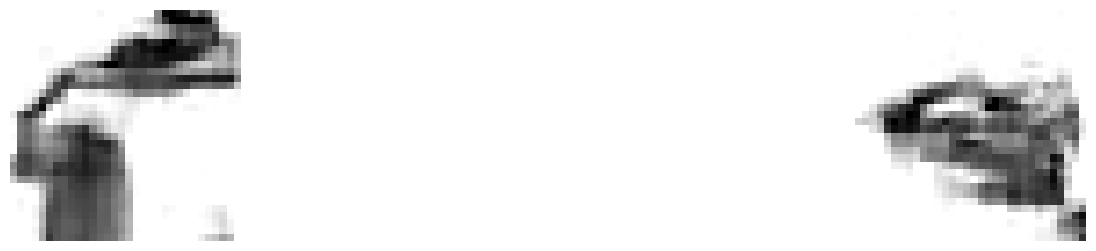

469/469 [==============================] - 210s 449ms/step - loss: 2079.1472
Epoch 3/10
469/469 [==============================] - ETA: 0s - loss: 2003.3495
Saved to ./output/generated_img_002.png


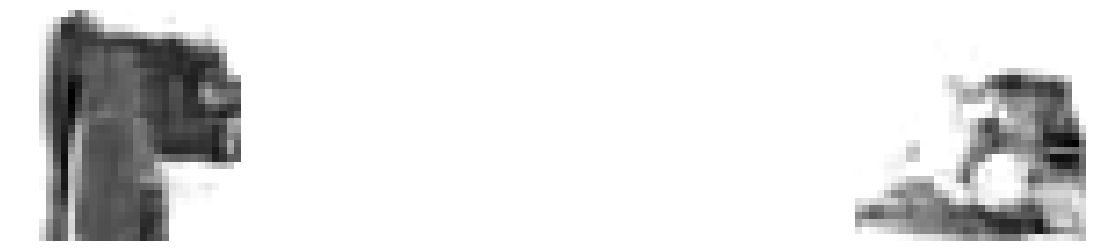

469/469 [==============================] - 210s 448ms/step - loss: 2003.3495
Epoch 4/10
469/469 [==============================] - ETA: 0s - loss: 1953.9089
Saved to ./output/generated_img_003.png


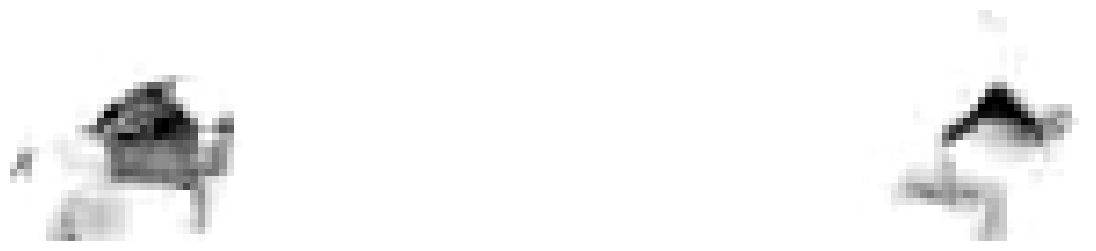

469/469 [==============================] - 209s 446ms/step - loss: 1953.9089
Epoch 5/10
469/469 [==============================] - ETA: 0s - loss: 1910.8782
Saved to ./output/generated_img_004.png


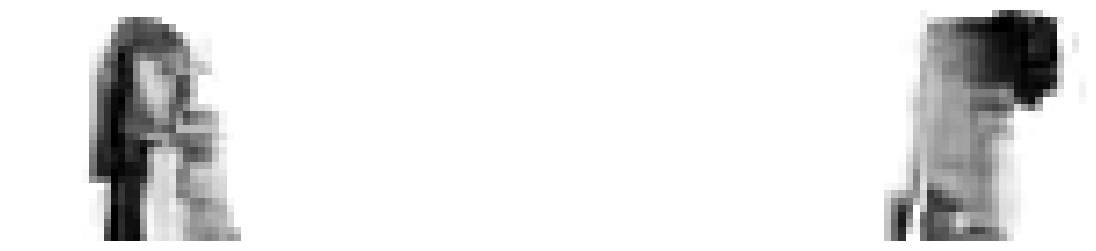

469/469 [==============================] - 212s 453ms/step - loss: 1910.8782
Epoch 6/10
469/469 [==============================] - ETA: 0s - loss: 1880.7954
Saved to ./output/generated_img_005.png


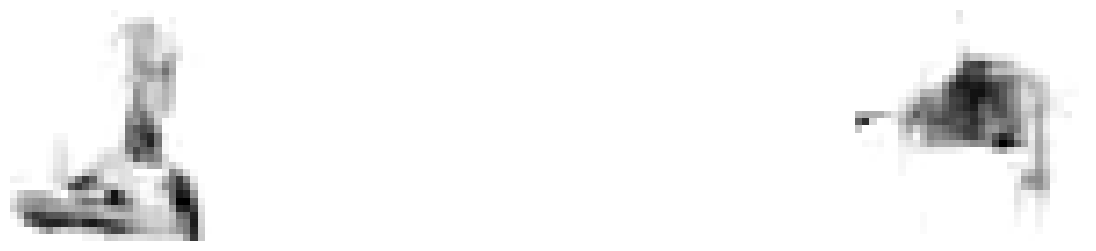

469/469 [==============================] - 214s 457ms/step - loss: 1880.7954
Epoch 7/10
469/469 [==============================] - ETA: 0s - loss: 1852.3691
Saved to ./output/generated_img_006.png


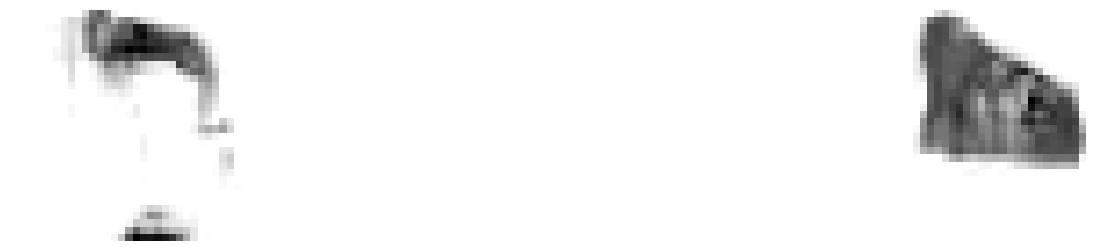

469/469 [==============================] - 214s 457ms/step - loss: 1852.3691
Epoch 8/10
469/469 [==============================] - ETA: 0s - loss: 1832.8744
Saved to ./output/generated_img_007.png


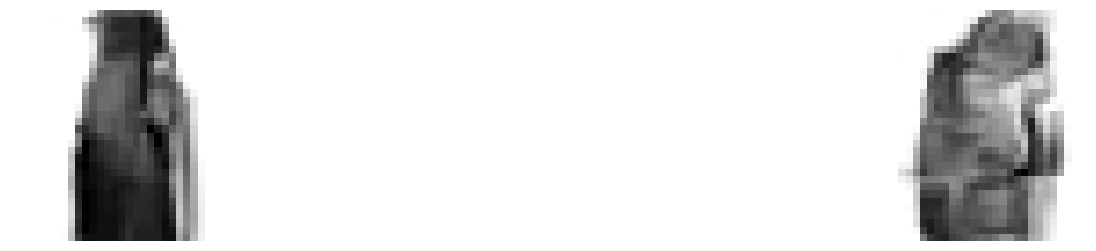

469/469 [==============================] - 213s 454ms/step - loss: 1832.8744
Epoch 9/10
469/469 [==============================] - ETA: 0s - loss: 1817.9786
Saved to ./output/generated_img_008.png


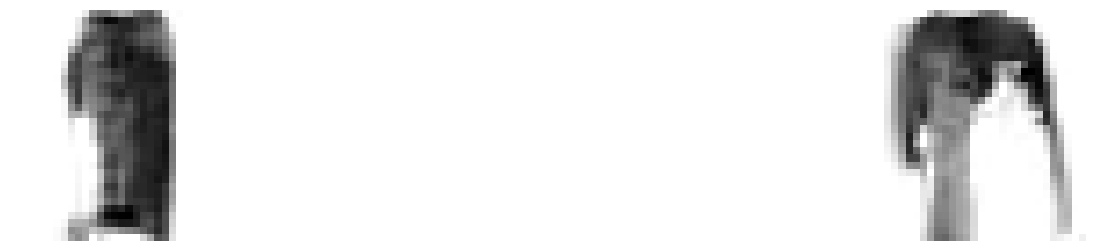

469/469 [==============================] - 214s 458ms/step - loss: 1817.9786
Epoch 10/10
469/469 [==============================] - ETA: 0s - loss: 1801.3215
Saved to ./output/generated_img_009.png


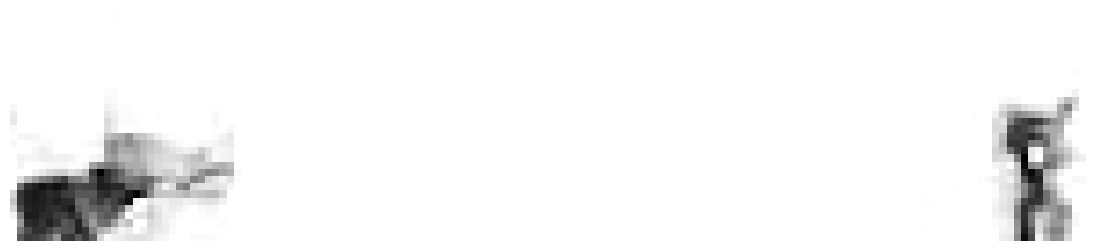

469/469 [==============================] - 215s 458ms/step - loss: 1801.3215


In [18]:
pixelcnn.fit(
    input_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback],
)

## 4. Generate images <a name="generate"></a>

In [19]:
generated_images = img_generator_callback.generate()

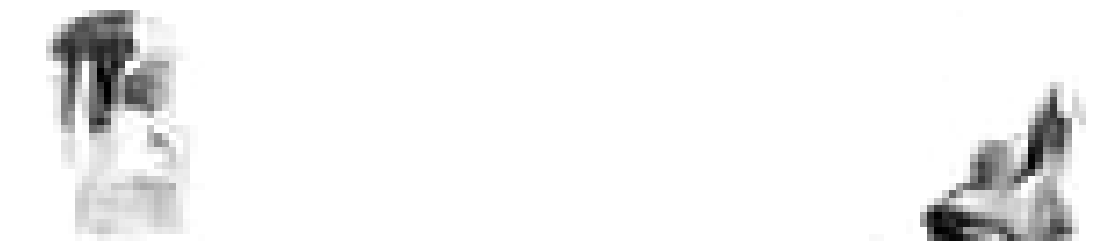

In [20]:
display(generated_images, n=img_generator_callback.num_img)